# BaristaSeq_VISp

In [1]:
import warnings
warnings.filterwarnings("ignore")
import MENDER
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.metrics import *
import time

In [2]:
## load the data using pysodb, please install pysodb in advance [https://pysodb.readthedocs.io/en/latest/]
import pysodb
sodb = pysodb.SODB()
adata_dict = sodb.load_dataset('Sun2021Integrating')


load experiment[Slice_1] in dataset[Sun2021Integrating]
load experiment[Slice_3] in dataset[Sun2021Integrating]
load experiment[Slice_2] in dataset[Sun2021Integrating]


In [3]:
# specify slice_id and ground truth
adata_list = []
for si in adata_dict.keys():
    adata = adata_dict[si]
    adata.obs['slice_id'] = si
    adata_list.append(adata)
adata_raw = adata_list[0].concatenate(adata_list[1:])
adata_raw.obs['slice_id'] = adata_raw.obs['slice_id'].astype('category')
adata_raw.obs['gt'] = adata_raw.obs['layer'].astype('category')




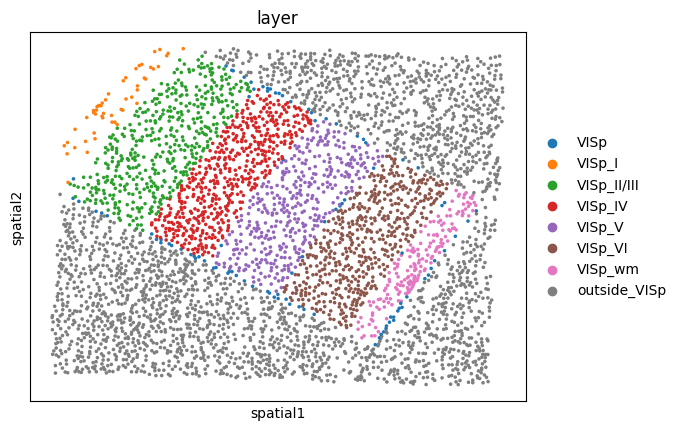

In [4]:
sc.pl.embedding(adata,basis='spatial',color='layer')

In [5]:
# remove invalid labels

adata_raw = adata_raw[(adata_raw.obs['layer']!='VISp') & (adata_raw.obs['layer']!='outside_VISp')]



In [6]:

batch_obs = 'slice_id'
gt_obs = 'layer'

In [10]:
# input parameters of MENDER
scale = 6
radius = 15

# estimate number of domains
n_cls = np.unique(adata.obs[gt_obs]).shape[0]


# record running time 
time_st = time.time()


adata = adata_raw.copy()



######### determine cell state using standard Leiden [start]  #########
# this step can be optionally skipped if reliable cell type annotation is available
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=4000)
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)

sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata,resolution=2,key_added='ct',random_state=666)
adata.obs[batch_obs] = adata.obs[batch_obs].astype('category')
adata.obs['ct'] = adata.obs['ct'].astype('category')
######### determine cell state using standard Leiden [end]  #########


# main body of MENDER
msm = MENDER.MENDER(
    adata,
    batch_obs = batch_obs, 
    # determine which cell state to use
    # we use the cell state got by Leiden
    ct_obs='ct',
    random_seed=666
)


# set the MENDER parameters


msm.prepare()
msm.set_MENDER_para(
    # default of n_scales is 6
    n_scales=scale, 
    
    # for single cell data, nn_mode is set to 'radius' 
    nn_mode='radius',
    
    # default of n_scales is 15 um (see the manuscript for why).
    # MENDER also provide a function 'estimate_radius' for estimating the radius
    nn_para=radius, 

)
# construct the context representation
msm.run_representation_mp(
    200
    # the number of processings
)

# set the spatial clustering parameter
# positive values for the expected number of domains
# negative values for the clustering resolution
msm.run_clustering_normal(n_cls)

time_ed = time.time()
time_cost = time_ed-time_st




default number of process is 200
total batch: 3, running batch Slice_1
total batch: 3, running batch Slice_2
total batch: 3, running batch Slice_3
scale 0, median #cells per radius (r=15): 2.0
scale 0, median #cells per radius (r=15): 2.0
scale 0, median #cells per radius (r=15): 2.0
scale 1, median #cells per radius (r=15): 4.0
scale 1, median #cells per radius (r=15): 4.0
scale 1, median #cells per radius (r=15): 5.0
scale 2, median #cells per radius (r=15): 6.0
scale 2, median #cells per radius (r=15): 7.0
scale 2, median #cells per radius (r=15): 8.0
scale 3, median #cells per radius (r=15): 8.0
scale 3, median #cells per radius (r=15): 9.0
scale 4, median #cells per radius (r=15): 10.0
scale 3, median #cells per radius (r=15): 11.0
scale 5, median #cells per radius (r=15): 12.0
scale 4, median #cells per radius (r=15): 12.0
scale 4, median #cells per radius (r=15): 14.0
scale 5, median #cells per radius (r=15): 14.0
scale 5, median #cells per radius (r=15): 17.0
searching resoluti

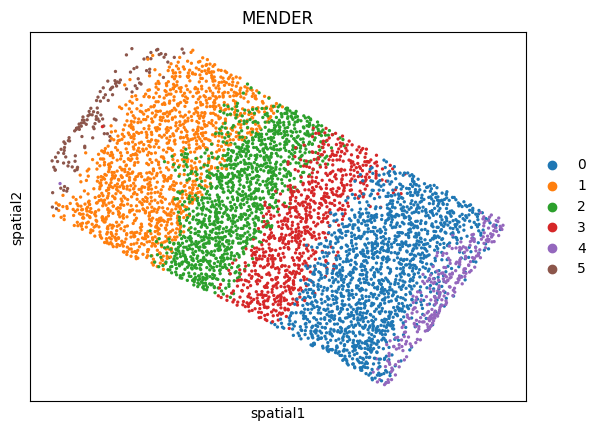

MENDER prediction


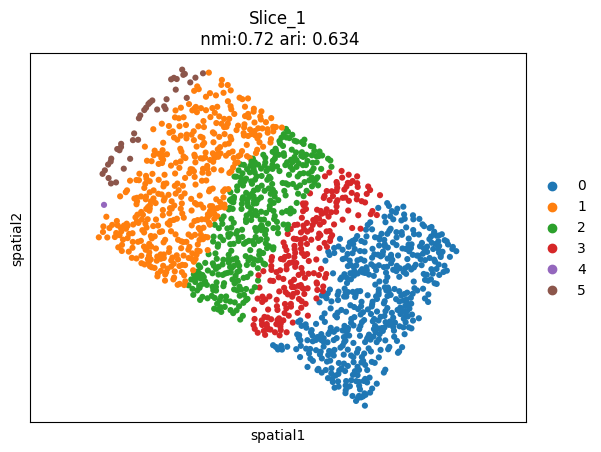

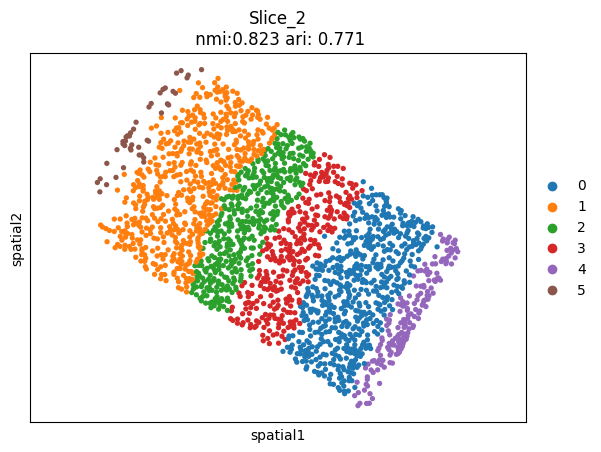

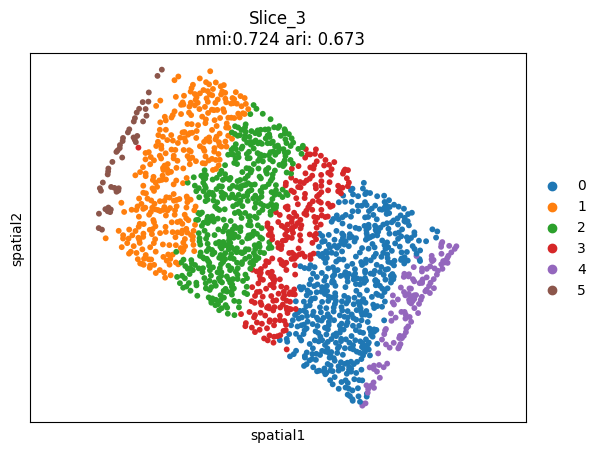

In [11]:
# the plot function has two parameters
# obs: the observation to plot
# gt_obs: the ground truth observation to compute NMI and ARI, can be set to None if not available
msm.output_cluster_all(obs='MENDER',obs_gt=gt_obs)
print('MENDER prediction')

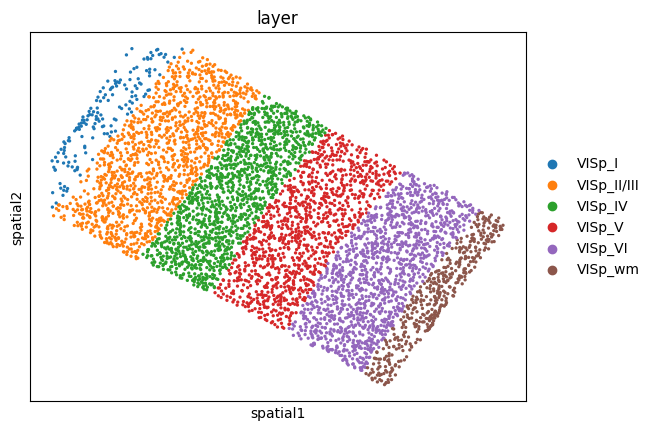

ground truth


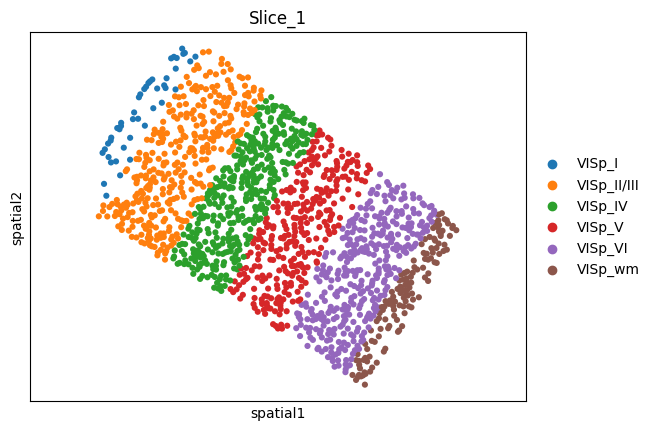

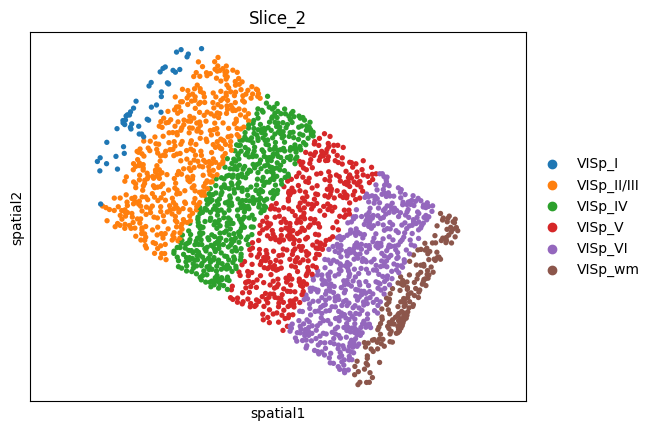

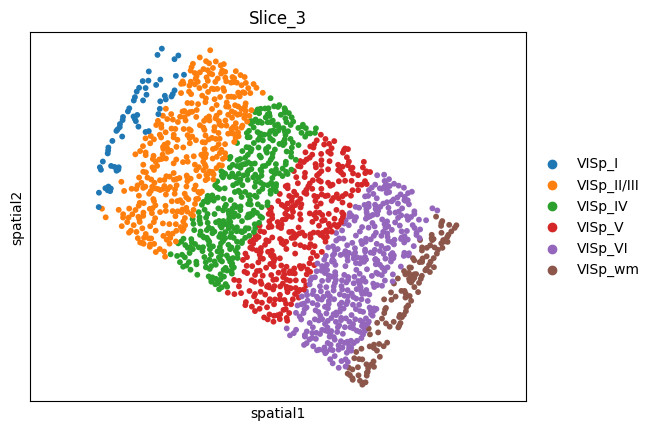

In [12]:
# the plot function has two parameters
# obs: the observation to plot
# gt_obs: the ground truth observation to compute NMI and ARI, can be set to None if not available

msm.output_cluster_all(obs=gt_obs,obs_gt=None)
print('ground truth')

In [13]:
print(f'running time: {time_cost} s')

running time: 10.623542070388794 s
